# Delta hedging strategy

In the first part of the project, we build a self-financing replicating portfolio based on the Delta hedging strategy within the Black-Scholes model.

### Determination of the Hedging Strategy

We define the Black-Scholes dynamics for the underlying asset under the real-world probability measure $\mathbb{P}$:
\begin{cases}
dS_t=\mu S_t dt + \sigma S_td W_t, \\
S_0 = 1.
\end{cases}

We define the dynamics of the bank account $B$:
\begin{cases}
dB_t = rB_t dt, \\
B_0 = 1.
\end{cases}

We define the hedging strategy as $(\alpha_t, \beta_t)$, where $\alpha_t$ is the quantity of the risky asset $S_t$ and $\beta_t$ is the quantity of the risk-free asset $B_t$ (bank account). The value of the portfolio is given by
$$
V_t = \alpha_t S_t + \beta_t B_t.
$$
Here, $\alpha_t$ and $\beta_t$ are adapted and "Markovian" processes, meaning they take the form $\alpha_t=\alpha(t,S_t)$ and $\beta_t=\beta(t,S_t)$, where $\alpha, \beta$ are functions of class $C^{1,2}([0,T[\times\mathbb{R}_{>0})$. In this way, if we define the value function as
$$
F(t,x) \coloneqq \alpha(t,x)x + \beta(t,x) e^{rt},
$$
the hedging strategy can be rewritten as
\begin{align}
V_t &= \alpha(t,S_t)S_t + \beta(t,S_t)B_t, \\
&= \alpha(t,S_t)S_t + \beta(t,S_t)e^{rt}, \\
&= F(t,S_t).
\end{align}

We impose two conditions:
1. The strategy must be self-financing, i.e.,
$dV_t = \alpha_t dS_t + \beta_t dB_t,$

2. At maturity, it must replicate the payoff of the Call option, meaning $F(T,x)=(x-K)^+$.

Substituting the dynamics into the stochastic differential of the value function, we obtain:
\begin{align}
dV_t &= \alpha_t \left(\mu S_t dt + \sigma S_t dW_t\right) + \beta_t r B_t dt,\\
&= (\alpha_t \mu S_t + \beta_t r B_t) dt + \alpha_t \sigma S_t dW_t.
\end{align}

Furthermore, since $V_t = F(t, S_t)$, by applying Itô's formula we can write the stochastic differential of the value function as:
\begin{align}
dV_t &= dF(t,S_t), \\
&= \partial_t F dt + \partial_x F dS_t + \frac{1}{2} \partial_{xx} F d\Braket{S}_t,\\
&= \left(\partial_t F + \mu S_t \partial_x F + \frac{1}{2} \sigma^2 S_t^2 \partial_{xx} F \right) dt + \sigma S_t \partial_x F dW_t.
\end{align}

By the uniqueness of the decomposition of Itô processes, the coefficients of the $dW_t$ and $dt$ terms in both expressions must be identical:
* **$dW_t$ term:**
  $$
  \alpha_t = \partial_x F =: \Delta.
  $$
  This quantity is known as **Delta** and represents the sensitivity of the option price with respect to changes in the underlying asset price. Furthermore, from the definition of the portfolio value, we have
  $$
  \beta_t = \frac{V_t - \alpha_t S_t}{B_t},
  $$
  which yields the replicating strategy $(\alpha_t, \beta_t)$ for the Call option.
  
* **$dt$ term:**
  $$
  \alpha_t \mu S_t + \beta_t r B_t = \partial_t F + \mu S_t \partial_x F + \frac{1}{2} \sigma^2 S_t^2 \partial_{xx} F.
  $$

From the definition of the portfolio value, $\beta_t B_t = F - \alpha_t S_t$. Substituting $\alpha_t = \partial_x F$, the equality for the $dt$ term becomes:
$$
\mu S_t \partial_x F + r(F - S_t \partial_x F) = \partial_t F + \mu S_t \partial_x F + \frac{1}{2} \sigma^2 S_t^2 \partial_{xx} F
$$

Simplifying the $\mu S_t \partial_x F$ term and leveraging the fact that $S_t \sim \text{log-normal}$, we obtain the Cauchy problem for the Black-Scholes equation:
\begin{cases}
\displaystyle\frac{\partial F}{\partial t}(t,x) + r x \frac{\partial F}{\partial x}(t,x) + \frac{1}{2} \sigma^2 x^2 \frac{\partial^2 F}{\partial x^2}(t,x) - r F(t,x) = 0,\quad \text{in } [0,T[\times\mathbb{R}_{>0},\\
\displaystyle F(T,x) = (x-K)^+, \quad x\in\mathbb{R}_{>0}.
\end{cases}

### Black-Scholes Formula

**Theorem**

Under the Black-Scholes model, the price at time $t$ of a European Call option, which solves the Cauchy problem, is given by:
$$
C_t = F(t, S_t) = S_t \Phi(d_1) - K e^{-r(T-t)} \Phi(d_2),
$$
where:
* $S_t$ is the price of the underlying asset at time $t$,
* $K$ is the strike price,
* $\Phi(x)$ is the cumulative distribution function (CDF) of the standard normal distribution,
* The coefficients $d_1, d_2$ are defined as:
\begin{align}
d_1 &= \frac{\log \left( \frac{S_t}{K} \right) + \left( r + \frac{\sigma^2}{2} \right) (T-t)}{\sigma \sqrt{T-t}}, \\
d_2 &= \frac{\log \left( \frac{S_t}{K} \right) + \left( r - \frac{\sigma^2}{2} \right) (T-t)}{\sigma \sqrt{T-t}} = d_1 - \sigma \sqrt{T-t}.
\end{align}

### Black-Scholes Delta

**Theorem**

Under the Black-Scholes model, we have:
$$
\Delta = \Phi(d_1).
$$

**Remark:** Since $0 < \Phi < 1$, the Delta of a Call option is always positive and strictly less than one. It represents the quantity of the underlying asset to hold in the replicating portfolio in order to hedge a short position on a Call.

Asymptotically, the following expressions hold for the Call price and its Delta:
\begin{align}
\lim_{S\to 0^+} C_t &= 0, & \lim_{S\to +\infty} C_t &= +\infty, \\
\lim_{S\to 0^+} \Delta &= 0, & \lim_{S\to +\infty} \Delta &= 1.
\end{align}

### Delta Value at Maturity

We observe that at maturity ($t = T$), the time to expiration becomes zero. Recall that:
$$
\Delta = \Phi(d_1)=\Phi\left(\frac{\log \left( \frac{S_t}{K} \right) + \left( r + \frac{\sigma^2}{2} \right) (T-t)}{\sigma \sqrt{T-t}}\right).
$$
Mathematically, the denominator of $d_1$ tends to zero, meaning that the argument of $\Phi$ tends to $+\infty$ or $-\infty$ depending on the sign of the numerator $\log(S_T/K)$:

* If the option is in-the-money ($S_T > K$): $$\lim_{T-t \to 0} \Phi(d_1) = \Phi(+\infty) = 1$$,
* If the option is out-of-the-money ($S_T < K$): $$\lim_{T-t \to 0} \Phi(d_1) = \Phi(-\infty) = 0$$.

Consequently, the randomness vanishes and the Delta becomes a deterministic indicator function: $\Delta = \mathbb{1}_{S_T>K}$. This ensures that the portfolio value matches the payoff at expiration, because:

* **If the option expires in-the-money:** $\Delta = 1$, meaning the trader holds exactly 1 share of the stock, and the hedging portfolio matches the payoff:
  $$
  V_T = 1\cdot S_T + \beta_TB_T = S_T - K.
  $$
  Upon exercise of the option, the trader delivers the share to the buyer in exchange for the strike price $K$ in cash. The cash balance accumulated through previous rebalancings, which equals $\beta_T B_T = -K$, is offset by the cash received. The overall balance closes at zero.

* **If the option expires out-of-the-money:** $\Delta = 0$, meaning the trader has already liquidated all shares in the market, and the hedging portfolio value is:
  $$
  V_T = 0\cdot S_T + \beta_TB_T = 0.
  $$
  Thus, the trading operations carried out during the strategy have generated an amount of cash such that the final liquid component $\beta_T B_T$ also converges to zero. The portfolio closes at zero.

## Implementation of the Hedging Strategy

### Discretization via the Euler Scheme

We write the dynamics of the log-price of the underlying asset. Setting $X_t=\log(S_t)$, by Itô's formula we have:
\begin{align}
dX_t &= \frac{1}{S_t}dS_t - \frac{1}{2S_t^2} d\braket{S}_t, \\
&= \mu dt + \sigma dW_t - \frac{\sigma^2}{2} dt, \\
&= \left(\mu - \frac{\sigma^2}{2}\right)dt + \sigma dW_t.
\end{align}
We then write the Euler discretization of the log-price over the subintervals $[t_k,t_{k+1}]$ of the partition of $[0,T]$:
$$
X_{t_{k+1}} = X_{t_k} + \left(\mu - \frac{\sigma^2}{2}\right) \Delta_k + \sigma\Delta W_k,\quad\quad\quad\Delta_k=t_{k+1}-t_k,\quad\Delta W_k\sim\mathcal{N}(0,\Delta_k),
$$
from which we obtain the discretized dynamics of the underlying asset:
\begin{cases}
S_{t_k}=e^{X_{t_k}},\quad\quad k=1,2,\dots,500,\\
S_0=1.
\end{cases}
In the code, this generation takes place inside the main loop for each simulation path.

### Hedging Strategy and Replicating Portfolio

To implement the hedging strategy, at each time step $t_k$ for $k=0,1,\dots,500$, we calculate the theoretical price of the Call option $V_{t_k}=V(t_k,S_{t_k})$ and its Delta $\Delta_{t_k}=\Delta(t_k,S_{t_k})$ according to the following scheme:

* **Initialization at time $t=0$:**
  The portfolio is established by collecting the option premium $V_0$. We purchase $\Delta_0$ units of the underlying asset. Given that the risk-free asset at the initial time is worth $B_0 = e^{r \cdot 0} = 1$, the initial number of units $\beta_0$ to hold in the bank account is the difference between the option value and the cost of the shares:

$$
V_0 = C_0,
$$

$$
\beta_0 = \frac{V_0 - \Delta_0 S_0}{B_0} = V_0 - \Delta_0 S_0.
$$

* **Dynamic Rebalancing at time steps $t_k$:**
  At any generic time step $t_k$, the risky asset takes the value $S_{t_k}$ and the risk-free asset has appreciated to $B_{t_k} = e^{r t_k}$. The value of the portfolio immediately before rebalancing, based on the allocations determined at the previous time step, is given by:
$$
V_{t_k} = \Delta_{t_{k-1}} S_{t_k} + \beta_{t_{k-1}} B_{t_k}.
$$
    We then compute the new delta $\Delta_{t_k}$ and update the cash position in the bank account:

$$
\beta_{t_k} = \frac{V_{t_k} - \Delta_{t_k} S_{t_k}}{B_{t_k}}.
$$

* **Evaluation of the Hedging Portfolio at Maturity $T$:**
  At the final step $t_n = T$, the value of the replicating portfolio is $V_T = \Delta_{t_{n-1}} S_T + \beta_{t_{n-1}} B_T$. This value is compared against the actual Call option payoff to determine the hedging error:

$$
\text{Error} = V_T - \max(S_T - K, 0).
$$

## Code

In [19]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import norm

In [21]:
def bs_call_price_delta(S, K, tau, r, sigma):
    
    with np.errstate(divide='ignore', invalid='ignore'):
        s = sigma * np.sqrt(tau)
        Krtau = np.exp(-r * tau) * K
        d1 = np.log(S / Krtau) / s + s / 2
        d2 = d1 - s
         
        price = S * stats.norm.cdf(d1) - Krtau * stats.norm.cdf(d2)
        price = np.where(np.isnan(price), 0.0, price)
        delta = stats.norm.cdf(d1)
     
    return price, delta


def hedging_bs(S0, B0, mu, sigma, r, K, T, n_steps, n_sims):
    # Time step size (Delta_t)
    dt = T / n_steps
     
    # Underlying asset initialization
    S = np.zeros((n_steps + 1, n_sims))
    S[0, :] = S0
     
    deltas = np.zeros((n_steps + 1, n_sims))
    betas = np.zeros((n_steps + 1, n_sims))
    call_prices = np.zeros((n_steps + 1, n_sims))
    portfolio = np.zeros((n_steps + 1, n_sims))
     
    # Value of the risk-free asset at each time step
    B = np.exp(r * np.arange(n_steps + 1) * dt)
     
    # Initialization at t=0
    V0, delta_0 = bs_call_price_delta(S0, K, T, r, sigma)
    deltas[0, :] = delta_0
    call_prices[0, :] = V0
    portfolio[0, :] = V0
    betas[0, :] = (V0 - delta_0 * S0) / B0
     
    for k in range(n_steps):
        # Calculate the remaining time to maturity
        tau = T - (k + 1) * dt
         
        # Compute the underlying asset dynamics
        Z = np.random.normal(0, 1, size=n_sims)
        S[k+1, :] = S[k, :] * np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
         
        # Calculate the theoretical Call price and delta at time t_{k+1} across all simulations
        call_prices[k+1, :], delta_next = bs_call_price_delta(S[k+1, :], K, tau, r, sigma)
         
        # Calculate the portfolio value before rebalancing
        portfolio[k+1, :] = (deltas[k, :] * S[k+1, :] + betas[k, :] * B[k+1])
         
        # Rebalancing
        if k < n_steps - 1:
            betas[k+1, :] = (portfolio[k+1, :] - delta_next * S[k+1, :]) / B[k+1]
            deltas[k+1, :] = delta_next
        else:
            # At maturity, delta is no longer a random variable:
            # It equals 1 if the option is exercised and 0 if it expires out-of-the-money.
            # This ensures that the hedging portfolio closes correctly in line with the payoff.
             
            deltas[k+1, :] = np.where(S[k+1, :] > K, 1.0, 0.0)
            betas[k+1, :] = 0.0 
     
     
    # Calculate hedging errors
    payoffs = np.maximum(S[-1, :] - K, 0)
    errors = portfolio[-1, :] - payoffs
     
    return {
        'errors': errors,
        'mean_error': np.mean(errors),
        'std_error': np.std(errors),
        'max_error': np.max(np.abs(errors)),
        'S': S,
        'portfolio': portfolio,
        'deltas': deltas,
        'call_prices': call_prices,
        'betas': betas
    }

In [23]:
# Parameters

S0 = 1.0        # Initial price of the risky asset
B0 = 1.0        # Initial value of the risk-free asset
mu = 0.02       # Real-world drift of the underlying asset
sigma = 0.30    # Volatility
r = 0.03        # Risk-free interest rate
T = 5.0         # Option maturity (in years)
K = 1.0         # Strike price
n_steps = 500   # Number of time steps N
n_sims = 10000  # Number of simulations for error statistics


results = hedging_bs(S0, B0, mu, sigma, r, K, T, n_steps, n_sims)
    
# Hedging Error Statistics
print("=" * 50)
print("Hedging Error Statistics:")
print("=" * 50)
print(f"Mean Error:      {results['mean_error']:>12.8f}")
print(f"Std of Errors:   {results['std_error']:>12.8f}")
print(f"Max |Error|:     {results['max_error']:>12.8f}")
print("=" * 50)

Hedging Error Statistics:
Mean Error:        0.00013558
Std of Errors:     0.01053114
Max |Error|:       0.08842537


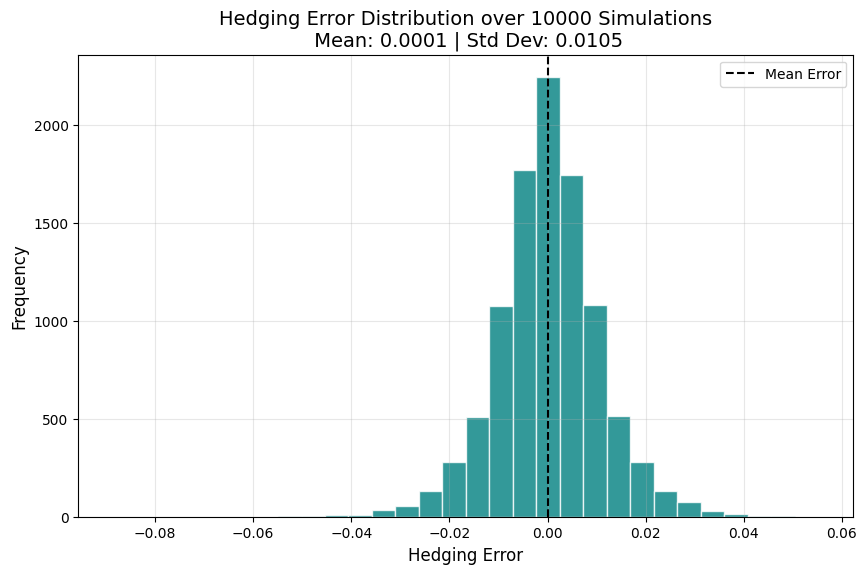

In [25]:
errors = results['errors']
std_errors = results['std_error']
mean_errors = results['mean_error']

# Frequency distribution of the hedging error
fig1, ax1 = plt.subplots(figsize=(10, 6))

ax1.hist(errors, bins=30, color='teal', edgecolor='white', alpha=0.8)
ax1.axvline(mean_errors, color='black', linestyle='--', label='Mean Error')
ax1.set_title(f"Hedging Error Distribution over {n_sims} Simulations\n Mean: {mean_errors:.4f} | Std Dev: {std_errors:.4f}", 
              fontsize=14)
ax1.set_xlabel("Hedging Error", fontsize=12)
ax1.set_ylabel("Frequency", fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()
plt.show()

### Error Analysis

The histogram represents the final error between the hedging portfolio value and the Call option payoff.
The bell-shaped curve we observe is due to time discretization: since we update the Delta only 500 times over 5 years, 
the market moves between rebalancings, leading to an accumulated hedging error.

The standard deviation measures the dispersion of the distribution of the errors committed.

## Delta Dynamics

Extracting data from the last simulation path to plot the time series

In [30]:
# Time array for plotting

dt = T / n_steps
t = np.arange(n_steps + 1) * dt

# Dynamics of the last simulation path
S_dinamica = results['S'][:, -1]
delta_dinamica = results['deltas'][:, -1]
portfolio_dinamica = results['portfolio'][:, -1]
call_prices_dinamica = results['call_prices'][:, -1]

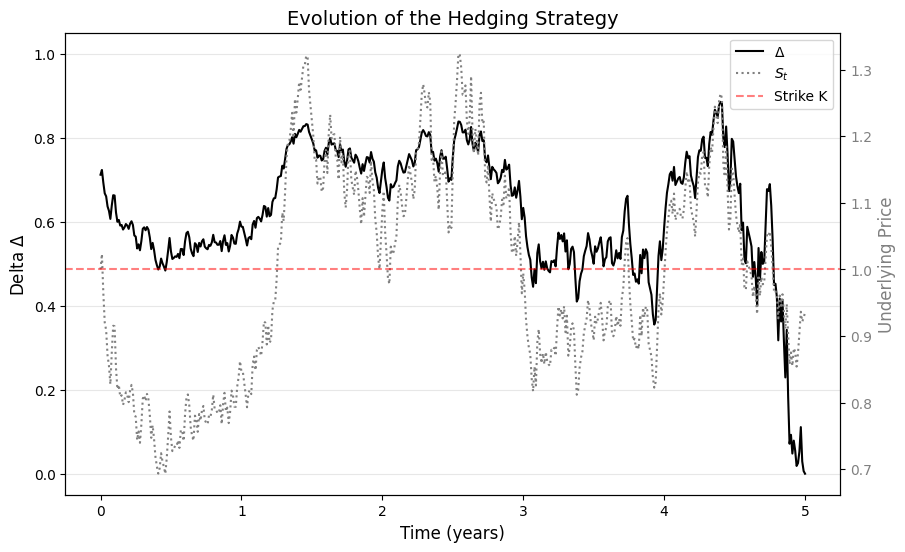

In [32]:
fig2, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(t, delta_dinamica, color='black', label='$\Delta$')
ax1.set_title("Evolution of the Hedging Strategy", fontsize=14)
ax1.set_xlabel("Time (years)", fontsize=12)
ax1.set_ylabel("Delta $\Delta$", color='black', fontsize=12)
ax1.set_ylim([-0.05, 1.05])
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, alpha=0.3, axis='y')

# Underlying asset price dynamics
ax2 = ax1.twinx()
ax2.plot(t, S_dinamica, color='gray', linestyle=':', label='$S_t$')
ax2.set_ylabel("Underlying Price", color='gray', fontsize=12)
ax2.axhline(K, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Strike K')
ax2.tick_params(axis='y', labelcolor='gray')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=10)

plt.show()

The overlay of the hedging dynamics onto the underlying asset price path highlights the strategy's sensitivity: whenever the underlying price rises (approaching or exceeding the strike), the strategy requires increasing the equity exposure (Delta $\to$ 1); conversely, market downturns correspond to a reduction in the position (Delta $\to$ 0). This is consistent with the expression of Delta in the Black-Scholes model, $\Delta = \Phi(d_1)$, which is an increasing function with respect to the price of the underlying asset. Furthermore, the Delta dynamics are also influenced by the remaining time to maturity $T - t$: the shorter the time, the more likely the Delta is to approach the boundaries of 0 or 1.

Finally, at maturity ($T=5$ years), Delta is no longer a random variable but is known with certainty: it equals 1 if the option is exercised and 0 if it expires worthless. This ensures that the hedging portfolio closes correctly in line with the payoff.

## Replicating Portfolio Value vs Call Option Price

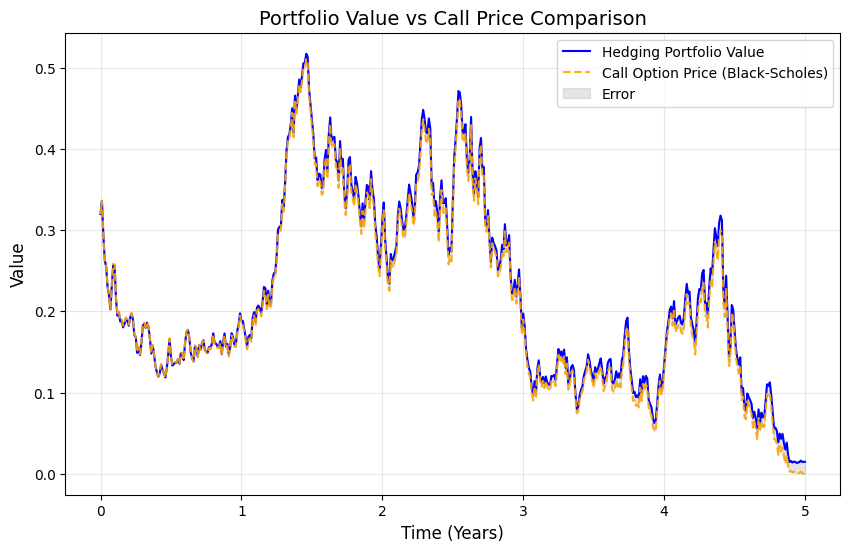

In [36]:
fig3, ax3 = plt.subplots(figsize=(10, 6))

ax3.plot(t, portfolio_dinamica, label='Hedging Portfolio Value', 
         color='blue')
ax3.plot(t, call_prices_dinamica, label='Call Option Price (Black-Scholes)', 
         color='orange', linestyle='--', alpha=0.9)
ax3.fill_between(t, portfolio_dinamica, call_prices_dinamica, 
                 alpha=0.2, color='gray', label='Error')
ax3.set_title("Portfolio Value vs Call Price Comparison", 
              fontsize=14)
ax3.set_xlabel("Time (Years)", fontsize=12)
ax3.set_ylabel("Value", fontsize=12)
ax3.legend(loc='best', fontsize=10)
ax3.grid(True, alpha=0.3)

plt.show()

## Evolution of the Hedging Strategy Error

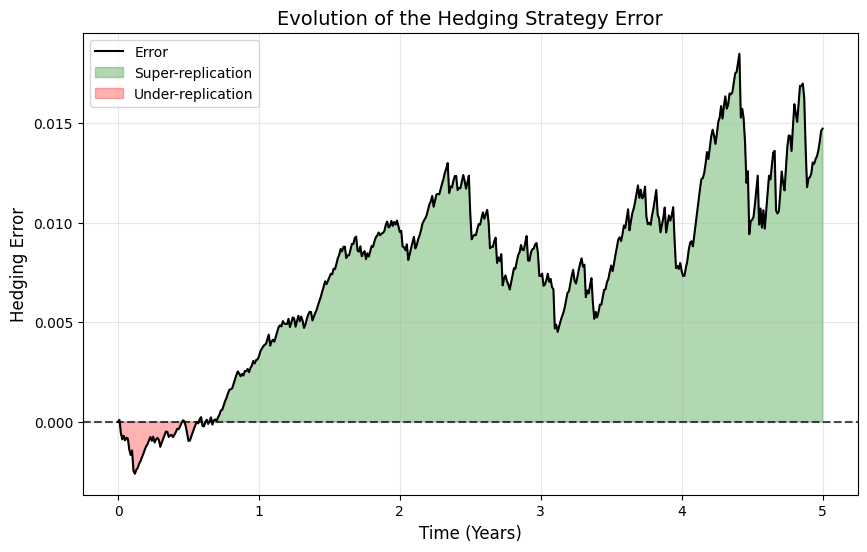

In [39]:
fig4, ax4 = plt.subplots(figsize=(10, 6))

# Calculate the error dynamics of the last simulation path
tracking_error = portfolio_dinamica - call_prices_dinamica

ax4.plot(t, tracking_error, color='black', label='Error')
ax4.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# Fill positive and negative areas with different colors
ax4.fill_between(t, tracking_error, 0, where=(tracking_error >= 0), alpha=0.3, color='green', label='Super-replication')
ax4.fill_between(t, tracking_error, 0, where=(tracking_error < 0), alpha=0.3, color='red', label='Under-replication')

ax4.set_title("Evolution of the Hedging Strategy Error", fontsize=14)
ax4.set_xlabel("Time (Years)", fontsize=12)
ax4.set_ylabel("Hedging Error", fontsize=12)
ax4.legend(loc='best', fontsize=10)
ax4.grid(True, alpha=0.3)

plt.show()

## Heston Stochastic Volatility Dynamics

Now we implement the hedging strategy while the underlying asset dynamics are driven by the Heston stochastic volatility model.

In [42]:
def hedging_heston(S0, B0, mu, k, v0, theta, eta, rho, r, K, T, n_steps, n_sims, sigma_bs):
    
    dt = T / n_steps
    
    # Underlying asset initialization
    S = np.zeros((n_steps + 1, n_sims))
    S[0, :] = S0

    # Variance initialization
    v = np.zeros((n_steps + 1, n_sims))
    v[0, :] = v0

    # Underlying asset log-price initialization
    X = np.zeros((n_steps + 1, n_sims))
    X[0, :] = np.log(S0)
    
    deltas = np.zeros((n_steps + 1, n_sims))
    betas = np.zeros((n_steps + 1, n_sims))
    call_prices = np.zeros((n_steps + 1, n_sims))
    portfolio = np.zeros((n_steps + 1, n_sims))
    
    # Value of the risk-free asset at each time step
    B = np.exp(r * np.arange(n_steps + 1) * dt)
    
    # Initialization at t=0
    sigma_0 = np.sqrt(v0)
    V0, delta_0 = bs_call_price_delta(S0, K, T, r, sigma_0)
    deltas[0, :] = delta_0
    call_prices[0, :] = V0
    portfolio[0, :] = V0
    betas[0, :] = (V0 - delta_0 * S0) / B0
    
    for i in range(n_steps):
        # Remaining time to maturity
        tau = T - (i + 1) * dt
        
        dW1 = stats.norm.rvs(size=n_sims) * np.sqrt(dt)
        dW2 = stats.norm.rvs(size=n_sims) * np.sqrt(dt)
        
        # Variance update with a floor check for negative variance
        v_pos = np.maximum(v[i, :], 0)
        v[i+1, :] = v[i, :] + k*(theta - v_pos)*dt + eta*np.sqrt(v_pos)*dW2
        
        # Underlying asset price update
        X[i+1, :] = X[i, :] + (mu - 0.5*v_pos)*dt + np.sqrt((1 - rho**2)*v_pos)*dW1 + rho*np.sqrt(v_pos)*dW2
        S[i+1, :] = np.exp(X[i+1, :])
        
        # Calculate the theoretical Call price and delta at time t_{i+1} across all simulations
        call_prices[i+1, :], delta_next = bs_call_price_delta(S[i+1, :], K, tau, r, sigma_bs)
        
        # Calculate the portfolio value before rebalancing
        portfolio[i+1, :] = deltas[i, :]*S[i+1, :] + betas[i, :]*B[i+1]
        
        # Rebalancing
        if i < n_steps - 1:
            betas[i+1, :] = (portfolio[i+1, :] - delta_next*S[i+1, :]) / B[i+1]
            deltas[i+1, :] = delta_next
        else:
            # At maturity, delta is the call payoff
            # No rebalancing at maturity
            deltas[i+1, :] = np.where(S[i+1, :] > K, 1.0, 0.0)
            betas[i+1, :] = 0.0  
    
    # Calculate hedging errors
    payoffs = np.maximum(S[-1, :] - K, 0)
    errors = portfolio[-1, :] - payoffs
    
    return {
        'errors': errors,
        'mean_error': np.mean(errors),
        'std_error': np.std(errors),
        'max_error': np.max(np.abs(errors)),
        'S': S,
        'v': v,
        'portfolio': portfolio,
        'deltas': deltas,
        'call_prices': call_prices,
        'betas': betas
    }

### Choice of Heston Model Parameters

In this part of the project, we implement the Black-Scholes hedging strategy while the underlying asset dynamics are driven by the Heston stochastic volatility model. Consequently, when evaluating the hedge, the Delta must be computed using the Black-Scholes formula under the assumption of a constant volatility $\sigma = 30\%$.

The most consistent approach is to set the following parameters equal to the Black-Scholes variance:
$$
v_0 = \theta = \sigma^2 = 0.09.
$$

By virtue of this choice, we can assess the model risk and demonstrate what happens when Delta is calculated assuming constant volatility, while the underlying price actually evolves according to Heston dynamics. Any final hedging error observed will be entirely driven by volatility risk: volatility is not constant but fluctuates around its long-term mean and is correlated with the underlying asset price.

In [45]:
# Heston model parameters

S0 = 1.0                # Price of the risky asset
B0 = 1.0                # Price of the risk-free asset
mu = 0.02               # Drift
k = 5.0                 # Speed of mean reversion of the variance
v0 = sigma**2           # Initial variance, using the constant volatility from the Black-Scholes model
theta = sigma**2        # Long-term variance, using the constant volatility from the Black-Scholes model
eta = 0.3               # Volatility of variance (vol-of-vol)
rho = -0.7              # Correlation between the two Brownian motions
r = 0.03                # Risk-free interest rate
K = 1.0                 # Strike price
T = 5.0                 # Maturity


# Constant volatility chosen for the Black-Scholes strategy
sigma_bs = sigma
    
results_heston = hedging_heston(S0, B0, mu, k, v0, theta, eta, rho, r, K, T, n_steps, n_sims, sigma_bs)
    
# Hedging error statistics
print("Hedging error statistics under the Heston model:")
print("="*50)
print(f"Mean Error:      {results_heston['mean_error']:>12.8f}")
print(f"Std of Errors:   {results_heston['std_error']:>12.8f}")
print(f"Max |Error|:     {results_heston['max_error']:>12.8f}")
print("="*50)

Hedging error statistics under the Heston model:
Mean Error:        0.00161448
Std of Errors:     0.01541395
Max |Error|:       0.09965003


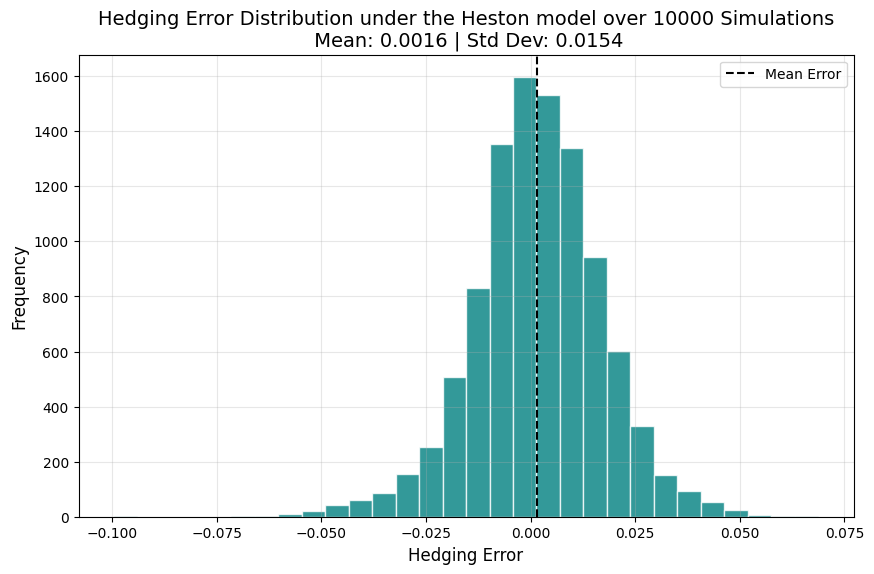

In [46]:
errors = results_heston['errors']
std_errors = results_heston['std_error']
mean_errors = results_heston['mean_error']

# Frequency distribution of the hedging error
fig1, ax1 = plt.subplots(figsize=(10, 6))

ax1.hist(errors, bins=30, color='teal', edgecolor='white', alpha=0.8)
ax1.axvline(mean_errors, color='black', linestyle='--', label='Mean Error')
ax1.set_title(f"Hedging Error Distribution under the Heston model over {n_sims} Simulations\n Mean: {mean_errors:.4f} | Std Dev: {std_errors:.4f}", 
              fontsize=14)
ax1.set_xlabel("Hedging Error", fontsize=12)
ax1.set_ylabel("Frequency", fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()
plt.show()

### Error Analysis

The analysis of the results shows that when applying the Black-Scholes hedging strategy to an underlying asset driven by Heston dynamics, the dispersion of the hedging error increases, as illustrated by the histogram. This phenomenon is a direct manifestation of model risk and can be justified by the following arguments:

* The Black-Scholes model assumes that the underlying asset price follows a log-normal distribution. Conversely, Heston dynamics (especially in the presence of a negative correlation $\rho = -0.7$) generate distributions characterized by:
  * Negative skewness: The probability of sharp downturns is higher compared to the Black-Scholes model.
  * Heavy tails (kurtosis): The probability of extreme events is greater than what is predicted by the normal distribution.

  Consequently, since the Black-Scholes Delta $\Delta = \Phi(d_1)$ is computed based on a distribution that differs from the actual market reality (modeled by Heston), the executed hedge turns out to be an approximation of the true Delta, leading to less efficient portfolio rebalancing.

* The Heston model is incomplete: It introduces a second source of uncertainty (the Brownian motion $W^2$). By hedging solely with the underlying asset, the financial practitioner leaves the volatility risk completely unhedged. Therefore, to achieve a perfect hedge within the Heston framework, it would be necessary to include another option in the replicating portfolio.